In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import ipywidgets as widgets
from IPython.display import display, clear_output

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)


Libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# Load dataset

file_path = "/content/creditcard.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Original shape:", df.shape)

display(df.head())


Dataset loaded successfully!
Original shape: (11959, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
# Dataset information and missing-value handling

print("Dataset information:")
df.info()

print("\nMissing values before cleaning:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nTotal missing values:", missing.sum())

df = df.dropna().copy()

print("\nAfter cleaning:")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Total missing values:", df.isnull().sum().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11959 entries, 0 to 11958
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11959 non-null  int64  
 1   V1      11959 non-null  float64
 2   V2      11959 non-null  float64
 3   V3      11959 non-null  float64
 4   V4      11959 non-null  float64
 5   V5      11959 non-null  float64
 6   V6      11959 non-null  float64
 7   V7      11959 non-null  float64
 8   V8      11959 non-null  float64
 9   V9      11959 non-null  float64
 10  V10     11959 non-null  float64
 11  V11     11959 non-null  float64
 12  V12     11959 non-null  float64
 13  V13     11959 non-null  float64
 14  V14     11959 non-null  float64
 15  V15     11959 non-null  float64
 16  V16     11959 non-null  float64
 17  V17     11959 non-null  float64
 18  V18     11959 non-null  float64
 19  V19     11959 non-null  float64
 20  V20     11958 non-null  float64
 21  V21     11958 

Class distribution:
Class
0.0    11906
1.0       52
Name: count, dtype: int64

Class percentage:
Class
0.0    99.565145
1.0     0.434855
Name: proportion, dtype: float64

0 = Normal | 1 = Fraud


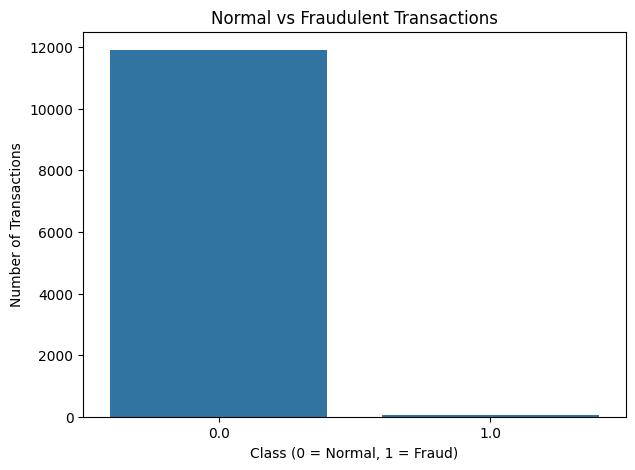


Transaction amount statistics:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,11906.0,62.198127,177.379105,0.0,5.2925,15.95,50.0000,7712.43
1.0,52.0,97.724808,321.188775,0.0,1.0000,1.00,1.7725,1809.68


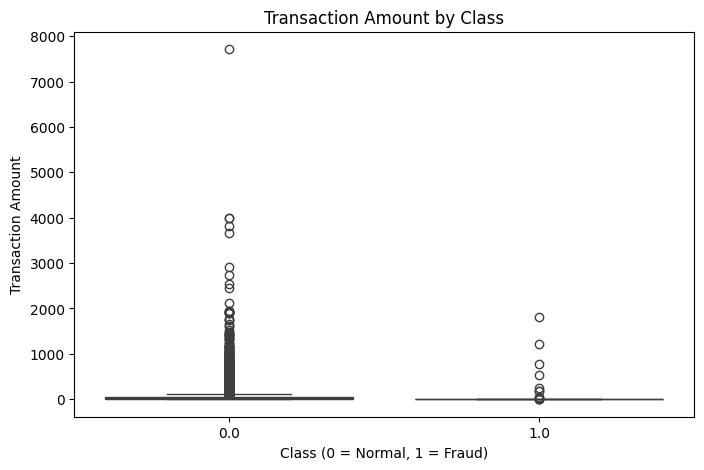

In [4]:
# Class distribution

class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class distribution:")
print(class_counts)

print("\nClass percentage:")
print(class_percent)

print("\n0 = Normal | 1 = Fraud")

plt.figure(figsize=(7, 5))
sns.countplot(x="Class", data=df)
plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()


# Transaction amount by class

print("\nTransaction amount statistics:")
display(df.groupby("Class")["Amount"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()


In [5]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Feature shape:", X.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


Feature shape: (11958, 30)
Training shape: (9566, 30)
Testing shape: (2392, 30)

Training class distribution:
Class
0    9524
1      42
Name: count, dtype: int64

Testing class distribution:
Class
0    2382
1      10
Name: count, dtype: int64


In [6]:
# Calculate class weights

normal_count = np.sum(y_train == 0)
fraud_count = np.sum(y_train == 1)
total = normal_count + fraud_count

class_weights = {
    0: total / (2 * normal_count),
    1: total / (2 * fraud_count)
}

print("Class weights:")
print(class_weights)


Class weights:
{0: np.float64(0.502204955900882), 1: np.float64(113.88095238095238)}


In [7]:
# Build and compile DNN

dnn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.30),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

dnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

dnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.7811 - auc: 0.5861 - loss: 0.7729 - precision: 0.0096 - recall: 0.4706 - val_accuracy: 0.9289 - val_auc: 0.9321 - val_loss: 0.5529 - val_precision: 0.0493 - val_recall: 0.8750
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9228 - auc: 0.8961 - loss: 0.4168 - precision: 0.0457 - recall: 0.8235 - val_accuracy: 0.9990 - val_auc: 0.9281 - val_loss: 0.3264 - val_precision: 0.8750 - val_recall: 0.8750
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9750 - auc: 0.9141 - loss: 0.3475 - precision: 0.1382 - recall: 0.8824 - val_accuracy: 0.9979 - val_auc: 0.9390 - val_loss: 0.1879 - val_precision: 0.7000 - val_recall: 0.8750
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9847 - auc: 0.9984 - loss: 0.1295 - precision: 0.2215 - recall: 0.9706 - val_accuracy: 0.9984 - val_auc: 0.9455 - val_loss: 0.0798 - val_precision: 0.7778 - val_recall: 0.8750
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━

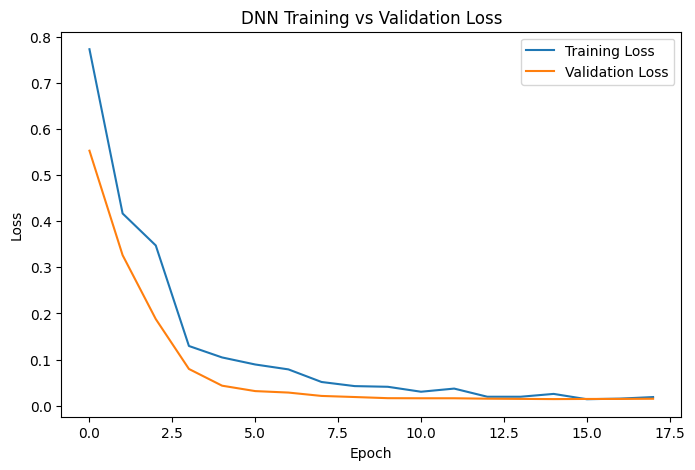

In [8]:
# Train DNN

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = dnn_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

# Training loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("DNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


DNN Classification Report
              precision    recall  f1-score   support

           0     0.9992    0.9992    0.9992      2382
           1     0.8000    0.8000    0.8000        10

    accuracy                         0.9983      2392
   macro avg     0.8996    0.8996    0.8996      2392
weighted avg     0.9983    0.9983    0.9983      2392

ROC-AUC : 0.8926
PR-AUC  : 0.6946


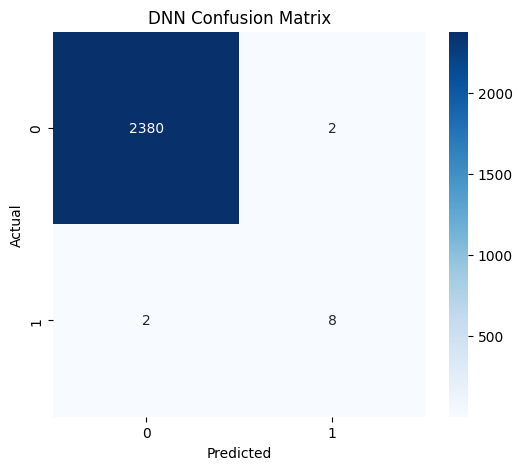

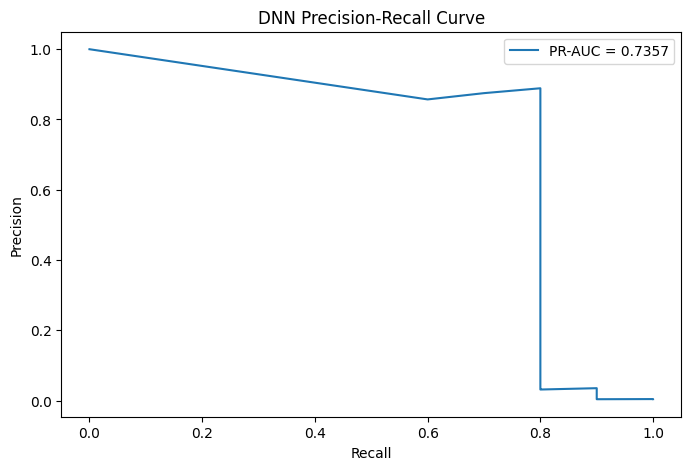

In [9]:
# DNN predictions and evaluation

y_prob_dnn = dnn_model.predict(X_test, verbose=0).ravel()
DNN_THRESHOLD = 0.50
y_pred_dnn = (y_prob_dnn >= DNN_THRESHOLD).astype(int)

dnn_accuracy = accuracy_score(y_test, y_pred_dnn)
dnn_precision = precision_score(y_test, y_pred_dnn, zero_division=0)
dnn_recall = recall_score(y_test, y_pred_dnn, zero_division=0)
dnn_f1 = f1_score(y_test, y_pred_dnn, zero_division=0)
roc_auc_dnn = roc_auc_score(y_test, y_prob_dnn)
pr_auc_dnn = average_precision_score(y_test, y_prob_dnn)

print("DNN Classification Report")
print(classification_report(y_test, y_pred_dnn, digits=4))

print(f"ROC-AUC : {roc_auc_dnn:.4f}")
print(f"PR-AUC  : {pr_auc_dnn:.4f}")

# Confusion matrix
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dnn, annot=True, fmt="d", cmap="Blues")
plt.title("DNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Precision-recall curve
precision_values, recall_values, _ = precision_recall_curve(
    y_test, y_prob_dnn
)

pr_auc_curve = auc(recall_values, precision_values)

plt.figure(figsize=(8, 5))
plt.plot(
    recall_values,
    precision_values,
    label=f"PR-AUC = {pr_auc_curve:.4f}"
)
plt.title("DNN Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


In [10]:
# Prepare normal transactions for Autoencoder training

X_train_normal = X_train[y_train.values == 0]

print("Normal transactions used for Autoencoder training:")
print(X_train_normal.shape)


# Build Autoencoder
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)
encoded = Dense(8, activation="relu")(encoded)

decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


Normal transactions used for Autoencoder training:
(9524, 30)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,334 (13.02 KB)

 Trainable params: 3,334 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - loss: 0.9130 - val_loss: 0.9077
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8734 - val_loss: 0.8585
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8155 - val_loss: 0.8030
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7531 - val_loss: 0.7526
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6982 - val_loss: 0.7126
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6591 - val_loss: 0.6852
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6310 - val_loss: 0.6584
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6034 - val_loss: 0.6294
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5771 - val_loss: 0.6093
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5538 - val_loss: 0.5867
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5342 - val_loss: 0.5699
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5174 - val

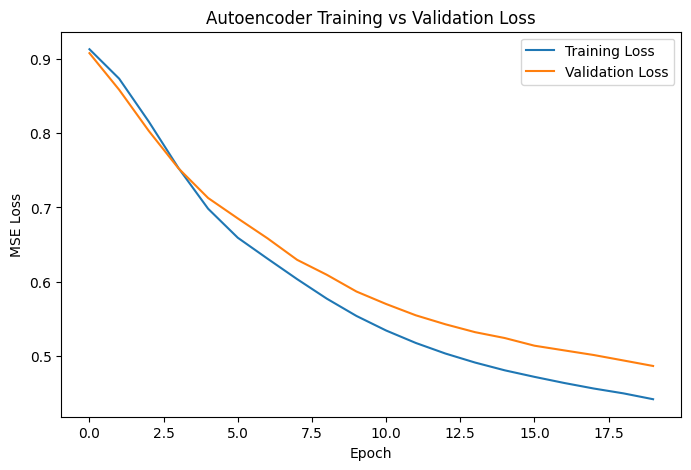

In [11]:
# Train Autoencoder

ae_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

ae_history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    validation_split=0.20,
    epochs=20,
    batch_size=256,
    shuffle=True,
    callbacks=[ae_early_stopping],
    verbose=1
)

plt.figure(figsize=(8, 5))
plt.plot(ae_history.history["loss"], label="Training Loss")
plt.plot(ae_history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


Autoencoder anomaly threshold: 1.0278047051668633
Autoencoder PR-AUC: 0.5778

Autoencoder Classification Report
              precision    recall  f1-score   support

           0     1.0000    0.9471    0.9728      2382
           1     0.0735    1.0000    0.1370        10

    accuracy                         0.9473      2392
   macro avg     0.5368    0.9736    0.5549      2392
weighted avg     0.9961    0.9473    0.9693      2392



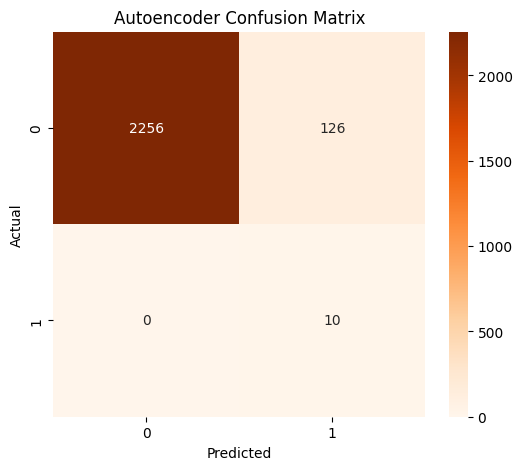

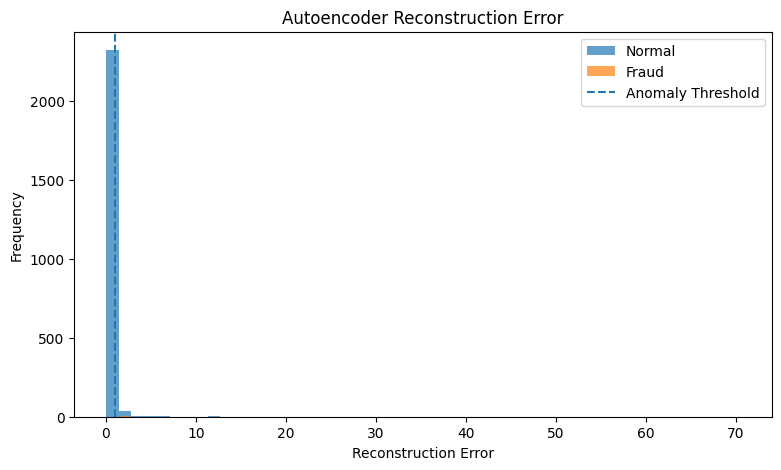

In [12]:
# Calculate normal reconstruction error and threshold

X_train_normal_reconstructed = autoencoder.predict(
    X_train_normal, verbose=0
)

normal_reconstruction_error = np.mean(
    np.square(X_train_normal - X_train_normal_reconstructed),
    axis=1
)

threshold = np.percentile(
    normal_reconstruction_error,
    95
)

print("Autoencoder anomaly threshold:", threshold)


# Test reconstruction error
X_test_reconstructed = autoencoder.predict(
    X_test, verbose=0
)

reconstruction_error = np.mean(
    np.square(X_test - X_test_reconstructed),
    axis=1
)

y_pred_ae = (reconstruction_error > threshold).astype(int)

pr_auc_ae = average_precision_score(
    y_test,
    reconstruction_error
)

print(f"Autoencoder PR-AUC: {pr_auc_ae:.4f}")

print("\nAutoencoder Classification Report")
print(classification_report(y_test, y_pred_ae, digits=4))


# Autoencoder confusion matrix
cm_ae = confusion_matrix(y_test, y_pred_ae)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ae, annot=True, fmt="d", cmap="Oranges")
plt.title("Autoencoder Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Reconstruction error distribution
plt.figure(figsize=(9, 5))
plt.hist(
    reconstruction_error[y_test.values == 0],
    bins=50,
    alpha=0.7,
    label="Normal"
)
plt.hist(
    reconstruction_error[y_test.values == 1],
    bins=50,
    alpha=0.7,
    label="Fraud"
)
plt.axvline(
    threshold,
    linestyle="--",
    label="Anomaly Threshold"
)
plt.title("Autoencoder Reconstruction Error")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


Sample risk analysis:


,Actual,DNN_Fraud_Probability,Anomaly_Score,Risk_Score,Risk_Level
0,0,0.000055,0.064471,1.938015,LOW RISK
1,0,0.000049,0.287319,8.623024,LOW RISK
2,0,0.000080,0.313252,9.403142,LOW RISK
3,0,0.000050,0.706564,21.200403,LOW RISK
4,0,0.000458,0.241359,7.272804,LOW RISK
5,0,0.002296,0.217728,6.692583,LOW RISK
6,0,0.000905,0.204687,6.203957,LOW RISK
7,0,0.006313,0.311003,9.772006,LOW RISK
8,0,0.000002,0.624407,18.732344,LOW RISK
9,0,0.000009,0.167298,5.019610,LOW RISK


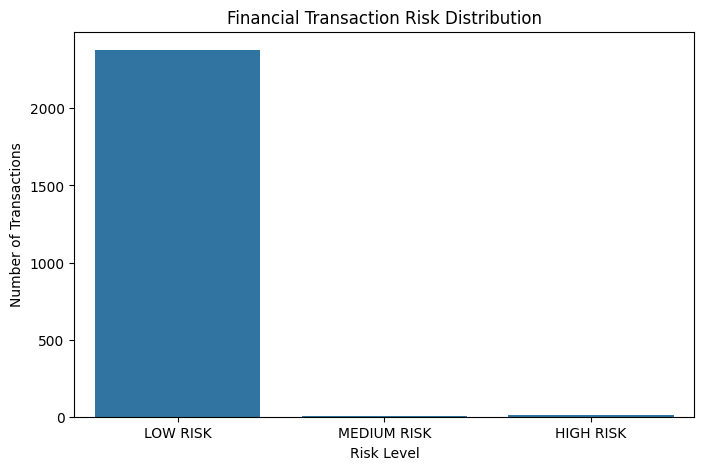

In [13]:
# Create financial risk analysis

results = pd.DataFrame({
    "Actual": y_test.values,
    "DNN_Fraud_Probability": y_prob_dnn,
    "DNN_Prediction": y_pred_dnn,
    "Autoencoder_Error": reconstruction_error,
    "Autoencoder_Prediction": y_pred_ae
})

# Convert reconstruction error into a 0-1 anomaly score
results["Anomaly_Score"] = (
    results["Autoencoder_Error"] / threshold
).clip(0, 1)

# Combined risk score
results["Risk_Score"] = (
    0.70 * results["DNN_Fraud_Probability"] +
    0.30 * results["Anomaly_Score"]
) * 100


def get_risk_level(score):
    if score >= 70:
        return "HIGH RISK"
    elif score >= 40:
        return "MEDIUM RISK"
    return "LOW RISK"


results["Risk_Level"] = results["Risk_Score"].apply(get_risk_level)

print("Sample risk analysis:")
display(
    results[
        [
            "Actual",
            "DNN_Fraud_Probability",
            "Anomaly_Score",
            "Risk_Score",
            "Risk_Level"
        ]
    ].head(10)
)

# Risk distribution
risk_order = ["LOW RISK", "MEDIUM RISK", "HIGH RISK"]

plt.figure(figsize=(8, 5))
sns.countplot(
    x="Risk_Level",
    data=results,
    order=risk_order
)
plt.title("Financial Transaction Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")
plt.show()


,Metric,DNN,Autoencoder
0,Accuracy,0.9983,0.9473
1,Precision,0.8000,0.0735
2,Recall,0.8000,1.0000
3,F1 Score,0.8000,0.1370
4,PR-AUC,0.6946,0.5778


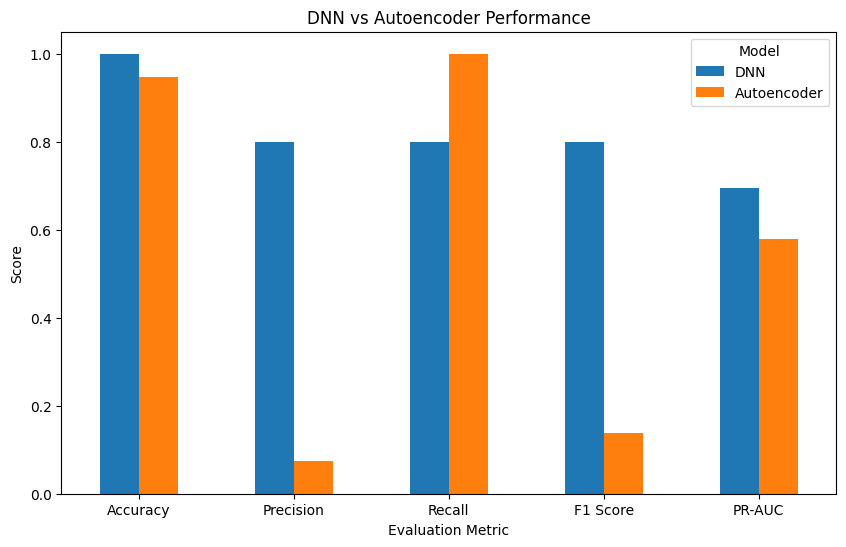

In [14]:
# Model comparison

ae_accuracy = accuracy_score(y_test, y_pred_ae)
ae_precision = precision_score(y_test, y_pred_ae, zero_division=0)
ae_recall = recall_score(y_test, y_pred_ae, zero_division=0)
ae_f1 = f1_score(y_test, y_pred_ae, zero_division=0)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "PR-AUC"],
    "DNN": [
        dnn_accuracy,
        dnn_precision,
        dnn_recall,
        dnn_f1,
        pr_auc_dnn
    ],
    "Autoencoder": [
        ae_accuracy,
        ae_precision,
        ae_recall,
        ae_f1,
        pr_auc_ae
    ]
})

display(comparison.round(4))

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("DNN vs Autoencoder Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()


In [15]:
# Interactive transaction analyzer

def analyze_transaction(transaction_id):
    if transaction_id < 0 or transaction_id >= len(X_test_raw):
        print(
            f"Invalid ID. Enter a value from 0 to {len(X_test_raw) - 1}."
        )
        return

    transaction = X_test_raw.iloc[transaction_id]
    actual_class = int(y_test.iloc[transaction_id])

    transaction_df = pd.DataFrame(
        [transaction.values],
        columns=X.columns
    )

    transaction_scaled = scaler.transform(transaction_df)

    # DNN
    fraud_probability = float(
        dnn_model.predict(transaction_scaled, verbose=0)[0][0]
    )

    # Autoencoder
    reconstructed = autoencoder.predict(
        transaction_scaled, verbose=0
    )

    error = float(
        np.mean(
            np.square(transaction_scaled - reconstructed)
        )
    )

    anomaly_score = min(error / threshold, 1.0)

    # Combined risk
    risk_score = (
        0.70 * fraud_probability +
        0.30 * anomaly_score
    ) * 100

    if risk_score >= 70:
        risk_level = "HIGH RISK"
        recommendation = (
            "Transaction requires immediate review "
            "and additional verification."
        )
    elif risk_score >= 40:
        risk_level = "MEDIUM RISK"
        recommendation = (
            "Transaction should undergo additional verification."
        )
    else:
        risk_level = "LOW RISK"
        recommendation = (
            "Transaction appears relatively normal."
        )

    actual_result = "FRAUD" if actual_class == 1 else "NORMAL"

    print("=" * 60)
    print("       CREDIT CARD TRANSACTION ANALYSIS")
    print("=" * 60)
    print(f"Transaction ID        : {transaction_id}")
    print(f"Transaction Amount    : {transaction['Amount']:.2f}")
    print(f"DNN Fraud Probability : {fraud_probability * 100:.2f}%")
    print(f"Autoencoder Anomaly   : {anomaly_score * 100:.2f}%")
    print(f"Combined Risk Score   : {risk_score:.2f}/100")
    print(f"Risk Level            : {risk_level}")
    print(f"Actual Dataset Class  : {actual_result}")
    print(f"Recommendation        : {recommendation}")
    print("=" * 60)


# Interactive controls
transaction_input = widgets.IntText(
    value=0,
    description="Transaction ID:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="350px")
)

analyze_button = widgets.Button(
    description="Analyze Transaction",
    button_style="primary",
    icon="search"
)

output_box = widgets.Output()


def on_analyze_clicked(_):
    with output_box:
        clear_output()
        analyze_transaction(transaction_input.value)


analyze_button.on_click(on_analyze_clicked)

print(
    f"Enter a test-set transaction ID from 0 to {len(X_test_raw) - 1}:"
)

display(
    transaction_input,
    analyze_button,
    output_box
)


Enter a test-set transaction ID from 0 to 2391:


IntText(value=0, description='Transaction ID:', layout=Layout(width='350px'), style=DescriptionStyle(descripti…

Button(button_style='primary', description='Analyze Transaction', icon='search', style=ButtonStyle())

Output()

In [16]:
# Display transaction IDs for demonstration

normal_ids = np.where(y_test.values == 0)[0]
fraud_ids = np.where(y_test.values == 1)[0]

print("NORMAL TRANSACTION IDs:")
print(normal_ids[:10].tolist())

print("\nFRAUD TRANSACTION IDs:")
print(fraud_ids[:10].tolist())

print(f"\nTotal normal transactions in test set: {len(normal_ids)}")
print(f"Total fraud transactions in test set : {len(fraud_ids)}")


NORMAL TRANSACTION IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

FRAUD TRANSACTION IDs:
[25, 268, 531, 660, 1012, 1025, 1335, 1851, 1883, 2047]

Total normal transactions in test set: 2382
Total fraud transactions in test set : 10
